In [3]:
import os
import sys

main_path = os.path.dirname(os.getcwd())
sys.path.append(main_path)
print(main_path)

d:\PROJECTS\ChangeDetection\CD


In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [5]:
DATASET_PATH = os.path.join(main_path, 'Datasets', 'SECOND','test','T1')

In [9]:
def svd_noise_reduction(image, rank):
    U, S, Vt = np.linalg.svd(image, full_matrices=False)
    # Retain only the top rank singular values
    S_reduced = np.zeros_like(S)
    S_reduced[:rank] = S[:rank]
    # Reconstruct the denoised image
    noise_reduced_image = np.dot(U, np.dot(np.diag(S_reduced), Vt))
    # Clip values to ensure they remain in the valid range [0, 255]
    noise_reduced_image = np.clip(noise_reduced_image, 0, 255)
    return noise_reduced_image.astype(np.uint8)

def denoise_rgb_image(image, rank):
    # Split the image into its RGB channels
    r_channel, g_channel, b_channel = cv2.split(image)

    # Apply SVD noise reduction to each channel
    r_denoised = svd_noise_reduction(r_channel, rank)
    g_denoised = svd_noise_reduction(g_channel, rank)
    b_denoised = svd_noise_reduction(b_channel, rank)

    # Merge the denoised channels back together
    denoised_image = cv2.merge((r_denoised, g_denoised, b_denoised))
    return denoised_image

In [28]:
# plot the histogram of 2 images
def plot_histogram(image1, image2):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.hist(image1.ravel(), bins=256, color='gray', alpha=0.7)
    plt.title('Histogram of Image 1')
    plt.subplot(1, 2, 2)
    plt.hist(image2.ravel(), bins=256, color='gray', alpha=0.7)
    plt.title('Histogram of Image 2')
    plt.show()

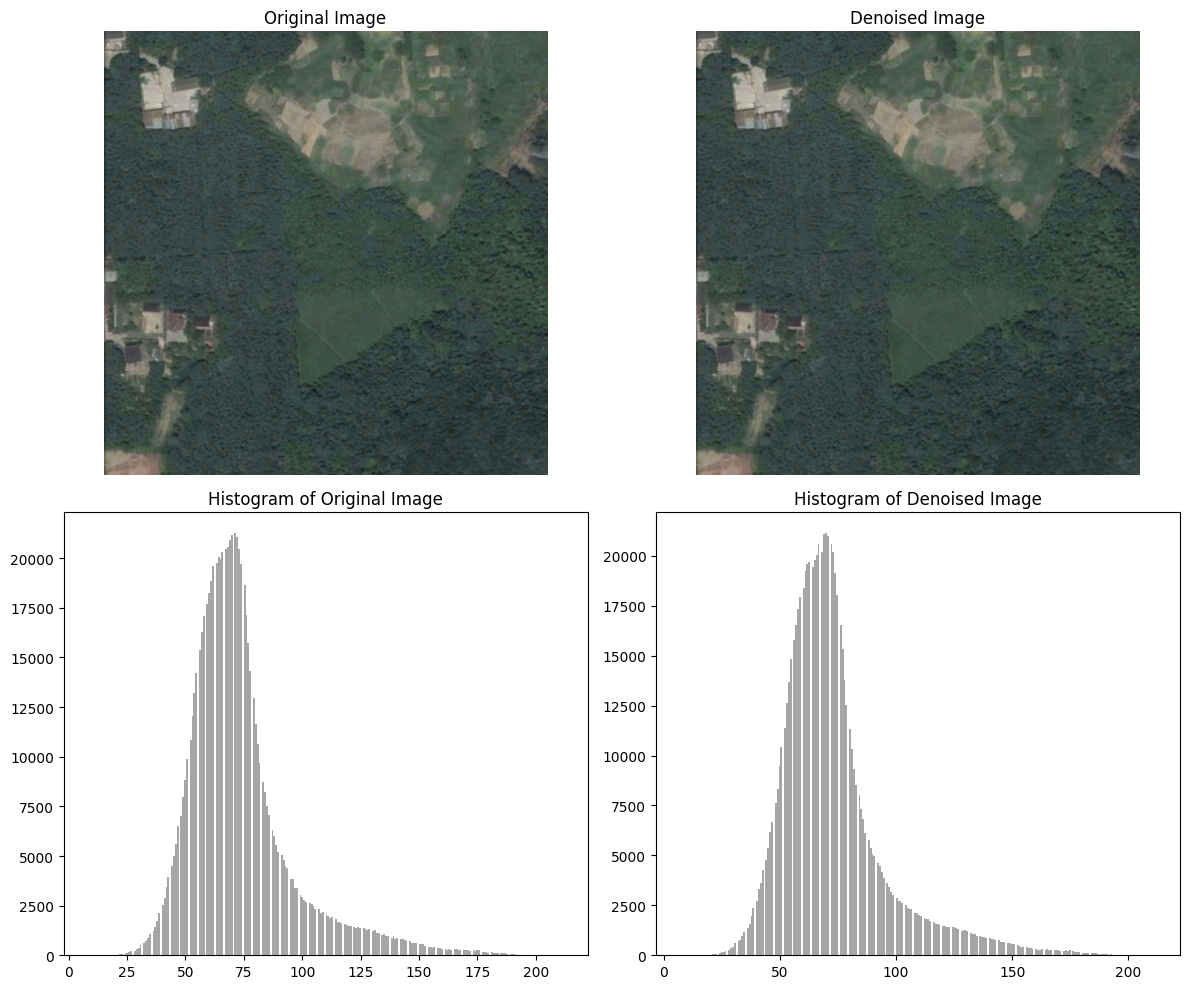

In [36]:
def plot_denoised_image(image_num):
    image_path = os.path.join(DATASET_PATH, f'{image_num:05d}.png')
    image = cv2.imread(image_path)
    plt.figure(figsize=(12, 10))
    
    # Plot original and denoised images
    plt.subplot(2, 2, 1)
    plt.title('Original Image')
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    rank = 1000  # Adjust the rank as needed for noise reduction
    denoised_image = denoise_rgb_image(image, rank)

    plt.subplot(2, 2, 2)
    plt.title('Denoised Image')
    plt.imshow(cv2.cvtColor(denoised_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    # Plot histograms
    plt.subplot(2, 2, 3)
    plt.hist(image.ravel(), bins=256, color='gray', alpha=0.7)
    plt.title('Histogram of Original Image')

    plt.subplot(2, 2, 4)
    plt.hist(denoised_image.ravel(), bins=256, color='gray', alpha=0.7)
    plt.title('Histogram of Denoised Image')

    plt.tight_layout()
    plt.show()

plot_denoised_image(4)


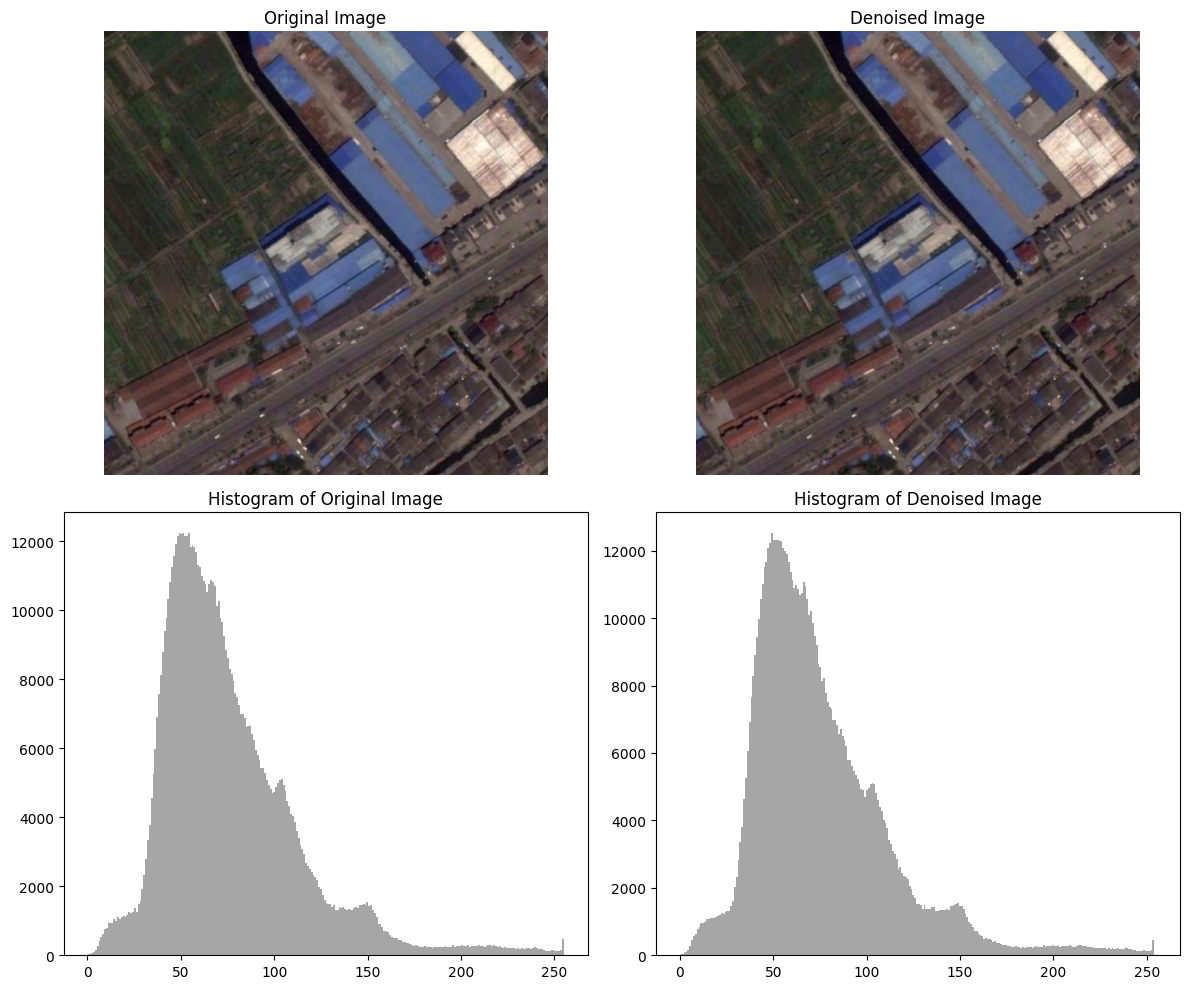

In [65]:
plot_denoised_image(1964)

In [39]:
import cv2
import gc
import numpy as np
import pandas as pd
import rasterio
from skimage.color import lab2lch, rgb2lab
from skimage.exposure import rescale_intensity
from skimage.morphology import disk
from sklearn.cluster import KMeans



def shadow_detection(image_file, shadow_mask_file, convolve_window_size = 5, num_thresholds = 3, struc_elem_size = 5):
    if (convolve_window_size % 2 == 0):
        raise ValueError('Please make sure that convolve_window_size is an odd integer')
        
    buffer = int((convolve_window_size - 1) / 2)
    
    
    with rasterio.open(image_file) as f:
        metadata = f.profile
        img = rescale_intensity(np.transpose(f.read(tuple(np.arange(metadata['count']) + 1)), [1, 2, 0]), out_range = 'uint8')
        img = img[:, :, 0 : 3]
    
    
    lch_img = np.float32(lab2lch(rgb2lab(img)))
    
    
    l_norm = rescale_intensity(lch_img[:, :, 0], out_range = (0, 1))
    h_norm = rescale_intensity(lch_img[:, :, 2], out_range = (0, 1))
    sr_img = (h_norm + 1) / (l_norm + 1)
    log_sr_img = np.log(sr_img + 1)
    
    del l_norm, h_norm, sr_img
    gc.collect()

    

    avg_kernel = np.ones((convolve_window_size, convolve_window_size)) / (convolve_window_size ** 2)
    blurred_sr_img = cv2.filter2D(log_sr_img, ddepth = -1, kernel = avg_kernel)
      
    
    del log_sr_img
    gc.collect()
    
                
    flattened_sr_img = blurred_sr_img.flatten().reshape((-1, 1))
    labels = KMeans(n_clusters = num_thresholds + 1, max_iter = 10000).fit(flattened_sr_img).labels_
    flattened_sr_img = flattened_sr_img.flatten()
    df = pd.DataFrame({'sample_pixels': flattened_sr_img, 'cluster': labels})
    threshold_value = df.groupby(['cluster']).min().max()[0]
    df['Segmented'] = np.uint8(df['sample_pixels'] >= threshold_value)
    
    
    del blurred_sr_img, flattened_sr_img, labels, threshold_value
    gc.collect()
    
    
    shadow_mask_initial = np.array(df['Segmented']).reshape((img.shape[0], img.shape[1]))
    struc_elem = disk(struc_elem_size)
    shadow_mask = np.expand_dims(np.uint8(cv2.morphologyEx(shadow_mask_initial, cv2.MORPH_CLOSE, struc_elem)), axis = 0)
    
    
    del df, shadow_mask_initial, struc_elem
    gc.collect()
    

    metadata['count'] = 1
    with rasterio.open(shadow_mask_file, 'w', **metadata) as dst:
        dst.write(shadow_mask)
        
    return shadow_mask



def shadow_correction(image_file, shadow_mask_file, corrected_image_file, exponent = 1):
    with rasterio.open(image_file) as f:
        metadata = f.profile
        img = rescale_intensity(np.transpose(f.read(tuple(np.arange(metadata['count']) + 1)), [1, 2, 0]), out_range = 'uint8')
        
    with rasterio.open(shadow_mask_file) as s:
        shadow_mask = s.read(1)
    
    corrected_img = np.zeros((img.shape), dtype = np.uint8)
    non_shadow_mask = np.uint8(shadow_mask == 0)
    
    
    for i in range(img.shape[2]):
        shadow_area_mask = shadow_mask * img[:, :, i]
        non_shadow_area_mask = non_shadow_mask * img[:, :, i]
        shadow_stats = np.float32(np.mean(((shadow_area_mask ** exponent) / np.sum(shadow_mask))) ** (1 / exponent))
        non_shadow_stats = np.float32(np.mean(((non_shadow_area_mask ** exponent) / np.sum(non_shadow_mask))) ** (1 / exponent))
        mul_ratio = ((non_shadow_stats - shadow_stats) / shadow_stats) + 1
        corrected_img[:, :, i] = np.uint8(non_shadow_area_mask + np.clip(shadow_area_mask * mul_ratio, 0, 255))
    

    with rasterio.open(corrected_image_file, 'w', **metadata) as dst:
        dst.write(np.transpose(corrected_img, [2, 0, 1]))
        
    return corrected_img

C:\Users\msi\AppData\Local\Temp\ipykernel_1816\1008365574.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  threshold_value = df.groupby(['cluster']).min().max()[0]
c:\Users\msi\AppData\Local\Programs\Python\Python312\Lib\site-packages\rasterio\__init__.py:378: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(
c:\Users\msi\AppData\Local\Programs\Python\Python312\Lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


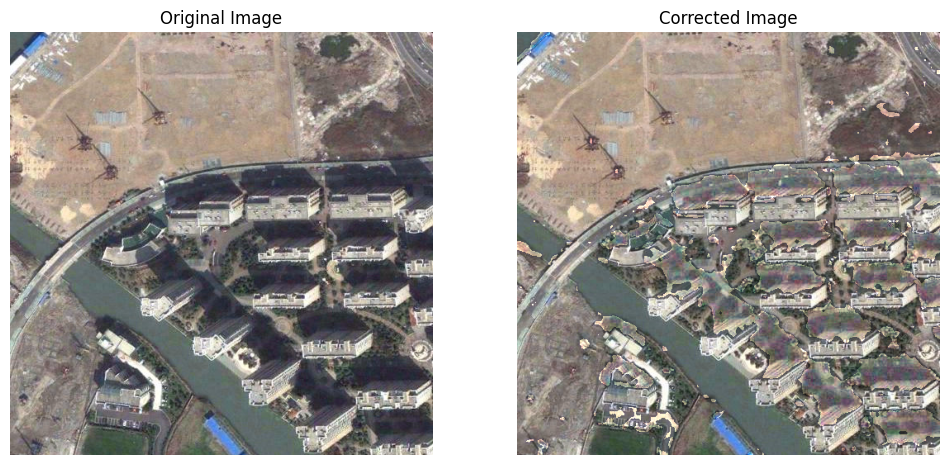

In [79]:
image_file = os.path.join(DATASET_PATH, '00064.png')
shadow_mask_file = os.path.join(main_path,"Experiments", 'shadow_mask.png')
corrected_image_file = os.path.join(main_path,"Experiments", 'corrected_image.png')
shadow_mask = shadow_detection(
    image_file, shadow_mask_file, convolve_window_size = 5, num_thresholds = 3, struc_elem_size = 1
)




corrected_image = shadow_correction(image_file, shadow_mask_file, corrected_image_file, exponent = 1)
plt.figure(figsize=(12, 10))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(cv2.cvtColor(cv2.imread(image_file), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title('Corrected Image')
plt.imshow(corrected_image)
plt.axis('off')
plt.show()